In [2]:
import pandas as pd
import numpy as np

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [3]:
X_train = pd.read_csv("../dataset/X_train.csv")
X_test = pd.read_csv("../dataset/X_test.csv")

y_train = pd.read_csv("../dataset/y_train.csv").values.ravel()
y_test = pd.read_csv("../dataset/y_test.csv").values.ravel()

In [ ]:
X_train.shape

(5625, 30)

In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [8]:
y_pred = model.predict(X_test)

print(y_pred[:10])

[False False  True False False False False  True False False]


In [ ]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.7874911158493249


In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

       False       0.83      0.89      0.86      1033
        True       0.62      0.52      0.56       374

    accuracy                           0.79      1407
   macro avg       0.73      0.70      0.71      1407
weighted avg       0.78      0.79      0.78      1407



In [11]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

print(cm)

[[915 118]
 [181 193]]


In [14]:
probabilities = model.predict_proba(X_test)

churn_prob = probabilities[:,1]

print(churn_prob[:10])

[0.00575411 0.12604418 0.68118717 0.1174326  0.35916702 0.443508
 0.1285706  0.75223439 0.21801122 0.01795595]


In [15]:
def risk_level(p):
    if p < 0.3:
        return "Low Risk"
    elif p < 0.7:
        return "Medium Risk"
    else:
        return "High Risk"

risk_levels = [risk_level(p) for p in churn_prob]

print(risk_levels[:10])

['Low Risk', 'Low Risk', 'Medium Risk', 'Low Risk', 'Medium Risk', 'Medium Risk', 'Low Risk', 'High Risk', 'Low Risk', 'Low Risk']


In [16]:
def recommendation(risk):
    if risk == "High Risk":
        return "Offer discount or loyalty plan"
    elif risk == "Medium Risk":
        return "Offer promotional package"
    else:
        return "No action needed"

recommendations = [recommendation(r) for r in risk_levels]

In [17]:
results = pd.DataFrame({
    "Prediction": y_pred,
    "Churn Probability": churn_prob,
    "Risk Level": risk_levels,
    "Recommendation": recommendations
})

results.head(10)

,Prediction,Churn Probability,Risk Level,Recommendation
0,False,0.005754,Low Risk,No action needed
1,False,0.126044,Low Risk,No action needed
2,True,0.681187,Medium Risk,Offer promotional package
3,False,0.117433,Low Risk,No action needed
4,False,0.359167,Medium Risk,Offer promotional package
5,False,0.443508,Medium Risk,Offer promotional package
6,False,0.128571,Low Risk,No action needed
7,True,0.752234,High Risk,Offer discount or loyalty plan
8,False,0.218011,Low Risk,No action needed
9,False,0.017956,Low Risk,No action needed


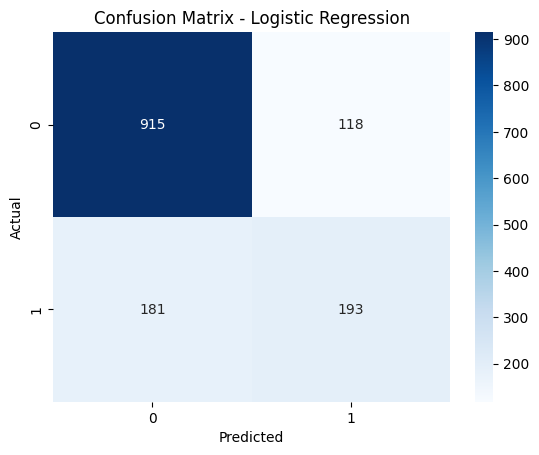

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

### Logistic Regression Model

Logistic Regression is a supervised machine learning algorithm used for classification problems.  
It predicts the probability that a given input belongs to a particular class.  

In this project, Logistic Regression is used to predict whether a telecom customer will churn or not based on customer attributes.

### Model Performance Analysis

The Logistic Regression model achieved an accuracy of approximately 79%.  
The model performs better at predicting non-churn customers compared to churn customers.  

This indicates that the dataset may be slightly imbalanced, which makes churn prediction more challenging.